In [1]:
import os
from pathlib import Path
from collections import Counter
import json
import shutil
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("=" * 60)
print("      SmartAgriVision - Dataset Analysis")
print("=" * 60)

print("\nLibraries Imported Successfully.")

print("\nVersions")
print("----------------------------")
print("Pandas :", pd.__version__)
print("NumPy  :", np.__version__)

      SmartAgriVision - Dataset Analysis

Libraries Imported Successfully.

Versions
----------------------------
Pandas : 3.0.5
NumPy  : 2.4.6


In [3]:
PROJECT_ROOT = Path(r"E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision")

In [4]:
DATASET_ROOT = PROJECT_ROOT / "SmartAgriVision_Dataset"

In [5]:
#datasets
FRUITS360_PATH = DATASET_ROOT / "Fruits-360"
NEW_PLANT_PATH = DATASET_ROOT / "New_Plant_Diseases"
PLANTDOC_PATH = DATASET_ROOT / "PlantDoc"
VEGETABLE_PATH = DATASET_ROOT / "Vegetable_Dataset"

In [6]:
# Display Paths
print("=" * 60)
print("Dataset Paths")
print("=" * 60)

print(f"Project Root   : {PROJECT_ROOT}")
print(f"Dataset Root   : {DATASET_ROOT}")
print(f"Fruits-360     : {FRUITS360_PATH}")
print(f"New Plant      : {NEW_PLANT_PATH}")
print(f"PlantDoc       : {PLANTDOC_PATH}")
print(f"Vegetable      : {VEGETABLE_PATH}")


Dataset Paths
Project Root   : E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision
Dataset Root   : E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\SmartAgriVision_Dataset
Fruits-360     : E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\SmartAgriVision_Dataset\Fruits-360
New Plant      : E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\SmartAgriVision_Dataset\New_Plant_Diseases
PlantDoc       : E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\SmartAgriVision_Dataset\PlantDoc
Vegetable      : E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\SmartAgriVision_Dataset\Vegetable_Dataset


In [7]:
# Check if folders exist
print("\nChecking Dataset Availability...\n")

datasets = {
    "Fruits-360": FRUITS360_PATH,
    "New Plant Diseases": NEW_PLANT_PATH,
    "PlantDoc": PLANTDOC_PATH,
    "Vegetable Dataset": VEGETABLE_PATH,
}

for name, path in datasets.items():
    if path.exists():
        print(f"✅ {name} : Found")
    else:
        print(f"❌ {name} : Not Found")


Checking Dataset Availability...

✅ Fruits-360 : Found
✅ New Plant Diseases : Found
✅ PlantDoc : Found
✅ Vegetable Dataset : Found


# Dataset Structure Analysis

In [8]:
print("=" * 80)
print("              DATASET STRUCTURE ANALYSIS")
print("=" * 80)

def show_dataset_structure(dataset_path, depth=2):

    dataset_path = Path(dataset_path)

    if not dataset_path.exists():
        print(f"\n❌ Dataset Not Found : {dataset_path}")
        return

    print(f"\n📂 {dataset_path.name}")

    def walk(folder, current_depth):

        if current_depth > depth:
            return

        items = sorted(folder.iterdir(), key=lambda x: (x.is_file(), x.name.lower()))

        for item in items:

            indent = "    " * current_depth

            if item.is_dir():
                print(f"{indent}📁 {item.name}")
                walk(item, current_depth + 1)

    walk(dataset_path, 1)


datasets = {
    "Fruits-360": FRUITS360_PATH,
    "New Plant Diseases": NEW_PLANT_PATH,
    "PlantDoc": PLANTDOC_PATH,
    "Vegetable Dataset": VEGETABLE_PATH
}

for name, path in datasets.items():

    print("\n")
    print("=" * 80)
    print(name)
    print("=" * 80)

    show_dataset_structure(path)
print("\n")
print("=" * 80)
print("Dataset Structure Analysis Completed Successfully.")
print("=" * 80)

              DATASET STRUCTURE ANALYSIS


Fruits-360

📂 Fruits-360
    📁 fruits-360_100x100
        📁 fruits-360


New Plant Diseases

📂 New_Plant_Diseases
    📁 train
        📁 Apple___Apple_scab
        📁 Apple___Black_rot
        📁 Apple___Cedar_apple_rust
        📁 Apple___healthy
        📁 Blueberry___healthy
        📁 Cherry_(including_sour)___healthy
        📁 Cherry_(including_sour)___Powdery_mildew
        📁 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
        📁 Corn_(maize)___Common_rust_
        📁 Corn_(maize)___healthy
        📁 Corn_(maize)___Northern_Leaf_Blight
        📁 Grape___Black_rot
        📁 Grape___Esca_(Black_Measles)
        📁 Grape___healthy
        📁 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
        📁 Orange___Haunglongbing_(Citrus_greening)
        📁 Peach___Bacterial_spot
        📁 Peach___healthy
        📁 Pepper,_bell___Bacterial_spot
        📁 Pepper,_bell___healthy
        📁 Potato___Early_blight
        📁 Potato___healthy
        📁 Potato___Lat

#  Dataset Statistics

In [41]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")
# Count Images
def count_images(folder):

    if folder is None:
        return 0

    folder = Path(folder)

    if not folder.exists():
        return 0

    total = 0

    for image_path in folder.rglob("*"):

        if (
            image_path.is_file()
            and image_path.suffix.lower() in IMAGE_EXTENSIONS
        ):
            total += 1

    return total

In [42]:
# Count Classes
def count_classes(folder):

    if folder is None:
        return 0

    folder = Path(folder)

    if not folder.exists():
        return 0

    return len([x for x in folder.iterdir() if x.is_dir()])


In [43]:
# Detect Train/Test/Validation
def detect_dataset(dataset_path):

    dataset_path = Path(dataset_path)

    train = None
    test = None
    validation = None

    for root, dirs, files in os.walk(dataset_path):

        folder = Path(root)

        name = folder.name.lower()

        if name in ["train", "training"]:

            train = folder

        elif name == "test":

            test = folder

        elif name in ["valid", "validation"]:

            validation = folder

    return train, test, validation

In [44]:
datasets = {
    "Fruits-360": FRUITS360_PATH,
    "New Plant Diseases": NEW_PLANT_PATH,
    "PlantDoc": PLANTDOC_PATH,
    "Vegetable Dataset": VEGETABLE_PATH
}

dataset_detection = []

for dataset_name, dataset_path in datasets.items():

    train_path, test_path, valid_path = detect_dataset(dataset_path)

    dataset_detection.append({

        "Dataset": dataset_name,

        "Train Folder":
            train_path.name if train_path else "Not Found",

        "Test Folder":
            test_path.name if test_path else "Not Found",

        "Validation Folder":
            valid_path.name if valid_path else "Not Found",

        "Train Path":
            str(train_path) if train_path else "-",

        "Test Path":
            str(test_path) if test_path else "-",

        "Validation Path":
            str(valid_path) if valid_path else "-"

    })

df_detection = pd.DataFrame(dataset_detection)

print("="*90)
print("DATASET DETECTION")
print("="*90)

display(df_detection)

DATASET DETECTION


,Dataset,Train Folder,Test Folder,Validation Folder,Train Path,Test Path,Validation Path
0,Fruits-360,Training,Test,Not Found,E:\programming languages\DJANGO PROJECT\SmartA...,E:\programming languages\DJANGO PROJECT\SmartA...,-
1,New Plant Diseases,train,Not Found,valid,E:\programming languages\DJANGO PROJECT\SmartA...,-,E:\programming languages\DJANGO PROJECT\SmartA...
2,PlantDoc,train,test,Not Found,E:\programming languages\DJANGO PROJECT\SmartA...,E:\programming languages\DJANGO PROJECT\SmartA...,-
3,Vegetable Dataset,train,test,validation,E:\programming languages\DJANGO PROJECT\SmartA...,E:\programming languages\DJANGO PROJECT\SmartA...,E:\programming languages\DJANGO PROJECT\SmartA...


In [45]:
results = []

for dataset_name, dataset_path in datasets.items():

    # Detect Dataset Structure
    train_path, test_path, valid_path = detect_dataset(dataset_path)

    # Count Images
    train_images = count_images(train_path)
    test_images = count_images(test_path)
    valid_images = count_images(valid_path)

    # Count Classes
    if train_path is not None:
        total_classes = count_classes(train_path)
    elif test_path is not None:
        total_classes = count_classes(test_path)
    else:
        total_classes = 0

    # Total Images
    total_images = train_images + test_images + valid_images

    # Store Results
    results.append({

        "Dataset": dataset_name,

        "Classes": total_classes,

        "Train Images": train_images,

        "Test Images": test_images,

        "Validation Images": valid_images,

        "Total Images": total_images

    })

In [46]:
# Create DataFrame
df_statistics = pd.DataFrame(results)
print("=" * 90)
print("DATASET STATISTICS")
print("=" * 90)

display(df_statistics)

DATASET STATISTICS


,Dataset,Classes,Train Images,Test Images,Validation Images,Total Images
0,Fruits-360,260,137221,45724,0,182945
1,New Plant Diseases,38,140590,0,35144,175734
2,PlantDoc,28,2670,252,0,2922
3,Vegetable Dataset,15,15000,3000,3000,21000


In [47]:
#Overall Summary
total_datasets = len(df_statistics)
total_classes = df_statistics["Classes"].sum()
total_train = df_statistics["Train Images"].sum()
total_test = df_statistics["Test Images"].sum()
total_validation = df_statistics["Validation Images"].sum()
total_images = df_statistics["Total Images"].sum()

print(f"Total Datasets : {total_datasets}")
print(f"Total Classes  : {total_classes}")
print(f"Train Images   : {total_train:,}")
print(f"Test Images    : {total_test:,}")
print(f"Validation     : {total_validation:,}")
print(f"Total Images   : {total_images:,}")

print("=" * 90)

Total Datasets : 4
Total Classes  : 341
Train Images   : 295,481
Test Images    : 48,976
Validation     : 38,144
Total Images   : 382,601


In [16]:
print("\nDataset Status\n")

missing_train = 0
missing_test = 0
missing_validation = 0

for _, row in df_detection.iterrows():

    dataset = row["Dataset"]

    train_status = row["Train Folder"] != "Not Found"
    test_status = row["Test Folder"] != "Not Found"
    validation_status = row["Validation Folder"] != "Not Found"

    if not train_status:
        missing_train += 1

    if not test_status:
        missing_test += 1

    if not validation_status:
        missing_validation += 1

    print(f"✓ {dataset}")

    print(f"   Train Folder      : {'Available' if train_status else 'Missing'}")
    print(f"   Test Folder       : {'Available' if test_status else 'Missing'}")
    print(f"   Validation Folder : {'Available' if validation_status else 'Missing'}")

    print("-" * 90)

print("\nSUMMARY\n")

print(f"Datasets Found            : {len(df_detection)} / {len(datasets)}")
print(f"Missing Train Folder      : {missing_train}")
print(f"Missing Test Folder       : {missing_test}")
print(f"Missing Validation Folder : {missing_validation}")

print("\nOverall Status : READY FOR AI ANALYSIS")

print("=" * 90)


Dataset Status

✓ Fruits-360
   Train Folder      : Available
   Test Folder       : Available
   Validation Folder : Missing
------------------------------------------------------------------------------------------
✓ New Plant Diseases
   Train Folder      : Available
   Test Folder       : Missing
   Validation Folder : Available
------------------------------------------------------------------------------------------
✓ PlantDoc
   Train Folder      : Available
   Test Folder       : Available
   Validation Folder : Missing
------------------------------------------------------------------------------------------
✓ Vegetable Dataset
   Train Folder      : Available
   Test Folder       : Available
   Validation Folder : Available
------------------------------------------------------------------------------------------

SUMMARY

Datasets Found            : 4 / 4
Missing Train Folder      : 0
Missing Test Folder       : 1
Missing Validation Folder : 2

Overall Status : READY FOR AI

# ADVANCED CLASS STATISTICS

In [17]:
IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".gif",
    ".webp"
)

In [18]:
# Count Images Inside One Class
def count_class_images(folder):

    folder = Path(folder)

    total = 0

    for ext in IMAGE_EXTENSIONS:

        total += len(list(folder.glob(f"*{ext}")))
        total += len(list(folder.glob(f"*{ext.upper()}")))

    return total


In [19]:
# Create Class Information
class_information = []

for dataset_name, dataset_path in datasets.items():

    train_path, test_path, valid_path = detect_dataset(dataset_path)

    if train_path is None:
        continue

    class_folders = [
        folder
        for folder in sorted(train_path.iterdir())
        if folder.is_dir()
    ]

    for class_folder in class_folders:

        class_information.append({

            "Dataset": dataset_name,

            "Class": class_folder.name,

            "Images": count_class_images(class_folder)

        })

In [20]:
# Create DataFrame
df_classes = pd.DataFrame(class_information)

print("=" * 90)
print("CLASS INFORMATION TABLE")
print("=" * 90)

display(df_classes)

CLASS INFORMATION TABLE


,Dataset,Class,Images
0,Fruits-360,Almonds 1,464
1,Fruits-360,Apple 10,1398
2,Fruits-360,Apple 11,860
3,Fruits-360,Apple 12,932
4,Fruits-360,Apple 13,1398
...,...,...,...
336,Vegetable Dataset,Papaya,2000
337,Vegetable Dataset,Potato,2000
338,Vegetable Dataset,Pumpkin,2000
339,Vegetable Dataset,Radish,2000


In [21]:
# Total Class Records
total_class_records = len(df_classes)

print(f"Total Class Records : {total_class_records}")

print("=" * 90)

Total Class Records : 341


In [22]:

#UNIQUE CLASS NAMES
unique_class_names = df_classes["Class"].nunique()

print(f"Unique Class Names : {unique_class_names}")



Unique Class Names : 341


In [23]:
duplicate_classes = df_classes[df_classes.duplicated(subset=["Class"], keep=False)]

duplicate_count = duplicate_classes["Class"].nunique()

print(f"Duplicate Class Count : {duplicate_count}")

print()

if duplicate_count == 0:

    print("✅ No Duplicate Class Names Found.")

else:

    print("Duplicate Class Names:\n")

    display(
        duplicate_classes.sort_values(["Class", "Dataset"])
    )


Duplicate Class Count : 0

✅ No Duplicate Class Names Found.


In [24]:
#Largest Classes
largest_classes = (
    df_classes
    .sort_values(by="Images", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(largest_classes)


,Dataset,Class,Images
0,New Plant Diseases,Soybean___healthy,8088
1,New Plant Diseases,Apple___Apple_scab,8064
2,New Plant Diseases,Orange___Haunglongbing_(Citrus_greening),8040
3,New Plant Diseases,Apple___healthy,8032
4,New Plant Diseases,"Pepper,_bell___healthy",7952
5,New Plant Diseases,Apple___Black_rot,7948
6,New Plant Diseases,Tomato___Tomato_Yellow_Leaf_Curl_Virus,7844
7,New Plant Diseases,Potato___Early_blight,7756
8,New Plant Diseases,Potato___Late_blight,7756
9,New Plant Diseases,Tomato___healthy,7704


In [25]:
#Smallest Classes
smallest_classes = (
    df_classes
    .sort_values(
        by=["Images", "Dataset", "Class"],
        ascending=[True, True, True]
    )
    .head(10)
    .reset_index(drop=True)
)

display(smallest_classes)

,Dataset,Class,Images
0,PlantDoc,Tomato_two_spotted_spider_mites_leaf,4
1,PlantDoc,Bell_pepper_leaf,68
2,PlantDoc,Tomato_leaf,88
3,PlantDoc,Tomato_leaf_mosaic_virus,88
4,PlantDoc,Cherry_leaf,94
5,PlantDoc,Soyabean_leaf,114
6,PlantDoc,Corn_Gray_leaf_spot,126
7,PlantDoc,grape_leaf,126
8,PlantDoc,grape_leaf_black_rot,142
9,PlantDoc,Bell_pepper_leaf_spot,148


In [26]:
#Average Images per Class
average_images = df_classes["Images"].mean()
print(f"Average Images per Class : {average_images:.2f}")


Average Images per Class : 1733.03


In [27]:
#Median Images per Class
median_images = df_classes["Images"].median()
print(f"Median Images per Class : {median_images:.2f}")


Median Images per Class : 984.00


In [28]:
#Maximum Images in One Class
max_images = df_classes["Images"].max()
print(f"Maximum Images in One Class : {max_images:,}")


Maximum Images in One Class : 8,088


In [29]:
#Minimum Images in One Class
minimum_images = df_classes["Images"].min()
print(f"Minimum Images in One Class : {minimum_images:,}")

Minimum Images in One Class : 4


In [30]:
#Dataset-wise Class Count
dataset_class_count = (
    df_classes
    .groupby("Dataset")
    .size()
    .reset_index(name="Total Classes")
    .sort_values("Total Classes", ascending=False)
)

display(dataset_class_count)

,Dataset,Total Classes
0,Fruits-360,260
1,New Plant Diseases,38
2,PlantDoc,28
3,Vegetable Dataset,15


In [31]:
#Dataset-wise Image Count
dataset_image_count = (
    df_classes
    .groupby("Dataset")["Images"]
    .sum()
    .reset_index(name="Total Images")
    .sort_values("Total Images", ascending=False)
)

display(dataset_image_count)

,Dataset,Total Images
1,New Plant Diseases,281180
0,Fruits-360,274442
3,Vegetable Dataset,30000
2,PlantDoc,5340


In [32]:
#Healthy vs Diseased Class Statistics
healthy_classes = df_classes[
    df_classes["Class"].str.contains(
        "healthy",
        case=False,
        na=False
    )
]

diseased_classes = df_classes[
    ~df_classes["Class"].str.contains(
        "healthy",
        case=False,
        na=False
    )
]

summary = pd.DataFrame({

    "Category": [
        "Healthy Classes",
        "Diseased Classes"
    ],

    "Number of Classes": [
        len(healthy_classes),
        len(diseased_classes)
    ],

    "Total Images": [
        healthy_classes["Images"].sum(),
        diseased_classes["Images"].sum()
    ]

})

display(summary)

,Category,Number of Classes,Total Images
0,Healthy Classes,12,89176
1,Diseased Classes,329,501786


In [33]:
#Final Summary Report
print(f"Total Class Records        : {len(df_classes):,}")
print(f"Unique Class Names         : {df_classes['Class'].nunique():,}")
print(f"Duplicate Class Names      : {df_classes['Class'].duplicated().sum():,}")
print(f"Average Images per Class   : {df_classes['Images'].mean():.2f}")
print(f"Median Images per Class    : {df_classes['Images'].median():.2f}")
print(f"Maximum Images in One Class: {df_classes['Images'].max():,}")
print(f"Minimum Images in One Class: {df_classes['Images'].min():,}")

print("=" * 90)

print("\nDataset-wise Summary\n")

summary = (
    df_classes
    .groupby("Dataset")
    .agg(
        Classes=("Class", "count"),
        Images=("Images", "sum"),
        Average=("Images", "mean")
    )
    .reset_index()
)

display(summary)

Total Class Records        : 341
Unique Class Names         : 341
Duplicate Class Names      : 0
Average Images per Class   : 1733.03
Median Images per Class    : 984.00
Maximum Images in One Class: 8,088
Minimum Images in One Class: 4

Dataset-wise Summary



,Dataset,Classes,Images,Average
0,Fruits-360,260,274442,1055.546154
1,New Plant Diseases,38,281180,7399.473684
2,PlantDoc,28,5340,190.714286
3,Vegetable Dataset,15,30000,2000.000000


# Image Resolution Analysis

In [39]:
# Scan All Images
IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".gif",
    ".webp"
)

image_records = []


print("SCANNING IMAGE RESOLUTIONS")


for dataset_name, dataset_path in datasets.items():

    dataset_path = Path(dataset_path)

    print(f"Scanning : {dataset_name}")

    for image_path in dataset_path.rglob("*"):

        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        try:

            with Image.open(image_path) as img:

                width, height = img.size

                image_records.append({

                    "Dataset": dataset_name,
                    "Width": width,
                    "Height": height,
                    "Resolution": f"{width} x {height}",
                    "Mode": img.mode

                })

        except Exception:
            continue

print()
print(f"Total Images Scanned : {len(image_records):,}")

SCANNING IMAGE RESOLUTIONS
Scanning : Fruits-360
Scanning : New Plant Diseases

Total Images Scanned : 382,601


In [40]:
# Scan All Images

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".gif",
    ".webp"
)

image_records = []

print("SCANNING IMAGE RESOLUTIONS")

for dataset_name, dataset_path in datasets.items():

    print(f"\nSTARTING : {dataset_name}")

    dataset_path = Path(dataset_path)

    print(f"PATH     : {dataset_path}")
    print(f"EXISTS   : {dataset_path.exists()}")

    for image_path in dataset_path.rglob("*"):

        if not image_path.is_file():
            continue

        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        try:

            with Image.open(image_path) as img:

                width, height = img.size

                image_records.append({
                    "Dataset": dataset_name,
                    "Width": width,
                    "Height": height,
                    "Resolution": f"{width} x {height}",
                    "Mode": img.mode
                })

        except Exception:
            continue

    print(f"COMPLETED : {dataset_name}")


print()
print("=" * 90)
print(f"Total Images Scanned : {len(image_records):,}")
print("=" * 90)

SCANNING IMAGE RESOLUTIONS

STARTING : Fruits-360
PATH     : E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\SmartAgriVision_Dataset\Fruits-360
EXISTS   : True
COMPLETED : Fruits-360

STARTING : New Plant Diseases
PATH     : E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\SmartAgriVision_Dataset\New_Plant_Diseases
EXISTS   : True
COMPLETED : New Plant Diseases

STARTING : PlantDoc
PATH     : E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\SmartAgriVision_Dataset\PlantDoc
EXISTS   : True
COMPLETED : PlantDoc

STARTING : Vegetable Dataset
PATH     : E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\SmartAgriVision_Dataset\Vegetable_Dataset
EXISTS   : True
COMPLETED : Vegetable Dataset

Total Images Scanned : 382,601


In [48]:
#Create Resolution DataFrame
resolution_df = pd.DataFrame(image_records)

print("=" * 90)
print("IMAGE RESOLUTION DATAFRAME")
print("=" * 90)

display(resolution_df)
print(f"Total Records : {len(resolution_df):,}")

IMAGE RESOLUTION DATAFRAME


,Dataset,Width,Height,Resolution,Mode
0,Fruits-360,100,100,100 x 100,RGB
1,Fruits-360,100,100,100 x 100,RGB
2,Fruits-360,100,100,100 x 100,RGB
3,Fruits-360,100,100,100 x 100,RGB
4,Fruits-360,100,100,100 x 100,RGB
...,...,...,...,...,...
382596,Vegetable Dataset,224,224,224 x 224,RGB
382597,Vegetable Dataset,224,224,224 x 224,RGB
382598,Vegetable Dataset,224,224,224 x 224,RGB
382599,Vegetable Dataset,224,224,224 x 224,RGB


Total Records : 382,601


In [49]:
#Dataset Resolution Summary
summary_resolution = (
    resolution_df
    .groupby("Dataset")
    .agg(
        Total_Images=("Resolution", "count"),
        Unique_Resolutions=("Resolution", "nunique")
    )
    .reset_index()
)

display(summary_resolution)


,Dataset,Total_Images,Unique_Resolutions
0,Fruits-360,182945,1
1,New Plant Diseases,175734,1
2,PlantDoc,2922,1763
3,Vegetable Dataset,21000,10


In [50]:
#Width Statistics
print(f"Minimum Width : {resolution_df['Width'].min()} px")
print(f"Maximum Width : {resolution_df['Width'].max()} px")
print(f"Average Width : {resolution_df['Width'].mean():.2f} px")
print(f"Median Width  : {resolution_df['Width'].median():.2f} px")

Minimum Width : 100 px
Maximum Width : 6000 px
Average Width : 184.66 px
Median Width  : 224.00 px


In [51]:
#Height Statistics
print(f"Minimum Height : {resolution_df['Height'].min()} px")
print(f"Maximum Height : {resolution_df['Height'].max()} px")
print(f"Average Height : {resolution_df['Height'].mean():.2f} px")
print(f"Median Height  : {resolution_df['Height'].median():.2f} px")

Minimum Height : 69 px
Maximum Height : 6000 px
Average Height : 183.81 px
Median Height  : 224.00 px


In [52]:
#Aspect Ratio Analysis
resolution_df["Aspect_Ratio"] = (
    resolution_df["Width"] / resolution_df["Height"]
).round(3)

display(
    resolution_df[
        ["Dataset", "Width", "Height", "Resolution", "Aspect_Ratio"]
    ].head(20)
)

print()
print("Unique Aspect Ratios :", resolution_df["Aspect_Ratio"].nunique())

,Dataset,Width,Height,Resolution,Aspect_Ratio
0,Fruits-360,100,100,100 x 100,1.0
1,Fruits-360,100,100,100 x 100,1.0
2,Fruits-360,100,100,100 x 100,1.0
3,Fruits-360,100,100,100 x 100,1.0
4,Fruits-360,100,100,100 x 100,1.0
5,Fruits-360,100,100,100 x 100,1.0
6,Fruits-360,100,100,100 x 100,1.0
7,Fruits-360,100,100,100 x 100,1.0
8,Fruits-360,100,100,100 x 100,1.0
9,Fruits-360,100,100,100 x 100,1.0



Unique Aspect Ratios : 698


In [53]:
#RGB vs Grayscale Analysis
mode_summary = (
    resolution_df["Mode"]
    .value_counts()
    .reset_index()
)

mode_summary.columns = ["Mode", "Images"]

display(mode_summary)

print()
print("Total Image Modes :", len(mode_summary))

,Mode,Images
0,RGB,382590
1,CMYK,5
2,RGBA,5
3,L,1



Total Image Modes : 4


In [58]:
# CORRUPTED / UNREADABLE IMAGE ANALYSIS
failed_images = []

for dataset_name, dataset_path in datasets.items():

    dataset_path = Path(dataset_path)

    print(f"\nChecking : {dataset_name}")

    image_paths = [
        p for p in dataset_path.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for image_path in tqdm(
        image_paths,
        desc=f"Checking {dataset_name}",
        unit="image"
    ):

        try:

            with Image.open(image_path) as img:

                # Verify image integrity
                img.verify()

        except Exception as e:

            failed_images.append({
                "Dataset": dataset_name,
                "Image": str(image_path),
                "Error": str(e)
            })


# Create DataFrame
corrupted_df = pd.DataFrame(failed_images)

print()
print("=" * 90)
print("CORRUPTED IMAGE REPORT")
print("=" * 90)

print(
    f"Total Corrupted / Unreadable Images : "
    f"{len(corrupted_df):,}"
)

print(
    f"Total Valid Images                  : "
    f"{382601 - len(corrupted_df):,}"
)


Checking : Fruits-360


Checking Fruits-360: 100%|██████████| 182945/182945 [00:50<00:00, 3604.34image/s]



Checking : New Plant Diseases


Checking New Plant Diseases: 100%|██████████| 175734/175734 [00:40<00:00, 4388.56image/s]



Checking : PlantDoc


Checking PlantDoc: 100%|██████████| 2922/2922 [00:00<00:00, 3461.87image/s]



Checking : Vegetable Dataset


Checking Vegetable Dataset: 100%|██████████| 21000/21000 [00:05<00:00, 3530.54image/s]


CORRUPTED IMAGE REPORT
Total Corrupted / Unreadable Images : 0
Total Valid Images                  : 382,601


In [59]:
display(corrupted_df.head(20))

""


In [60]:
#Common Resolution Analysis
common_resolutions = (
    resolution_df["Resolution"]
    .value_counts()
    .reset_index()
)

common_resolutions.columns = [
    "Resolution",
    "Images"
]

display(common_resolutions.head(20))

print()
print(
    "Most Common Resolution :",
    common_resolutions.iloc[0]["Resolution"]
)

print(
    "Image Count            :",
    f"{common_resolutions.iloc[0]['Images']:,}"
)

,Resolution,Images
0,100 x 100,182945
1,256 x 256,175734
2,224 x 224,20991
3,300 x 300,213
4,1600 x 1200,56
5,800 x 600,42
6,1024 x 768,34
7,1200 x 1600,23
8,640 x 480,21
9,500 x 375,19



Most Common Resolution : 100 x 100
Image Count            : 182,945


In [61]:
#Dataset-wise Aspect Ratio
aspect_summary = (
    resolution_df
    .groupby("Dataset")
    .agg(
        Total_Images=("Aspect_Ratio", "count"),
        Unique_Aspect_Ratios=("Aspect_Ratio", "nunique"),
        Minimum_Aspect_Ratio=("Aspect_Ratio", "min"),
        Maximum_Aspect_Ratio=("Aspect_Ratio", "max")
    )
    .reset_index()
)

display(aspect_summary)

,Dataset,Total_Images,Unique_Aspect_Ratios,Minimum_Aspect_Ratio,Maximum_Aspect_Ratio
0,Fruits-360,182945,1,1.000,1.000
1,New Plant Diseases,175734,1,1.000,1.000
2,PlantDoc,2922,695,0.339,4.747
3,Vegetable Dataset,21000,10,1.000,1.198


In [62]:
#Dataset-wise Image Mode
mode_summary_dataset = (
    resolution_df
    .groupby(["Dataset", "Mode"])
    .size()
    .reset_index(name="Images")
    .sort_values(
        ["Dataset", "Images"],
        ascending=[True, False]
    )
)

display(mode_summary_dataset)

,Dataset,Mode,Images
0,Fruits-360,RGB,182945
1,New Plant Diseases,RGB,175734
4,PlantDoc,RGB,2911
2,PlantDoc,CMYK,5
5,PlantDoc,RGBA,5
3,PlantDoc,L,1
6,Vegetable Dataset,RGB,21000


In [63]:
#Dataset-wise Resolution
dataset_resolution_counts = (
    resolution_df
    .groupby(["Dataset", "Resolution"])
    .size()
    .reset_index(name="Images")
)

most_common_resolution = (
    dataset_resolution_counts
    .sort_values(
        ["Dataset", "Images"],
        ascending=[True, False]
    )
    .groupby("Dataset")
    .head(1)
    .reset_index(drop=True)
)

display(most_common_resolution)

,Dataset,Resolution,Images
0,Fruits-360,100 x 100,182945
1,New Plant Diseases,256 x 256,175734
2,PlantDoc,300 x 300,213
3,Vegetable Dataset,224 x 224,20991


In [64]:
#Final Resolution Analysis
print(
    f"Total Images Analyzed        : "
    f"{len(resolution_df):,}"
)

print(
    f"Unique Resolutions           : "
    f"{resolution_df['Resolution'].nunique():,}"
)

print(
    f"Unique Aspect Ratios         : "
    f"{resolution_df['Aspect_Ratio'].nunique():,}"
)

print(
    f"Image Modes                  : "
    f"{resolution_df['Mode'].nunique():,}"
)

most_common_res = (
    resolution_df["Resolution"]
    .value_counts()
    .idxmax()
)

most_common_res_count = (
    resolution_df["Resolution"]
    .value_counts()
    .max()
)

print(
    f"Most Common Resolution       : "
    f"{most_common_res}"
)

print(
    f"Images at Most Common Res.   : "
    f"{most_common_res_count:,}"
)


Total Images Analyzed        : 382,601
Unique Resolutions           : 1,775
Unique Aspect Ratios         : 698
Image Modes                  : 4
Most Common Resolution       : 100 x 100
Images at Most Common Res.   : 182,945


# Image Quality Dataset Preparation

In [65]:
quality_df = resolution_df.copy()

print(f"Total Images Available : {len(quality_df):,}")

display(quality_df.head())

Total Images Available : 382,601


,Dataset,Width,Height,Resolution,Mode,Aspect_Ratio
0,Fruits-360,100,100,100 x 100,RGB,1.0
1,Fruits-360,100,100,100 x 100,RGB,1.0
2,Fruits-360,100,100,100 x 100,RGB,1.0
3,Fruits-360,100,100,100 x 100,RGB,1.0
4,Fruits-360,100,100,100 x 100,RGB,1.0


In [66]:
#Basic Image Quality Statistics
quality_statistics = (
    quality_df[
        ["Width", "Height", "Aspect_Ratio"]
    ]
    .describe()
    .round(3)
)

display(quality_statistics)

,Width,Height,Aspect_Ratio
count,382601.000,382601.000,382601.000
mean,184.660,183.808,1.001
std,120.881,110.747,0.031
min,100.000,69.000,0.339
25%,100.000,100.000,1.000
50%,224.000,224.000,1.000
75%,256.000,256.000,1.000
max,6000.000,6000.000,4.747


In [67]:
#Image Dimension Range
print(
    f"Minimum Width  : "
    f"{quality_df['Width'].min():,} px"
)

print(
    f"Maximum Width  : "
    f"{quality_df['Width'].max():,} px"
)

print(
    f"Minimum Height : "
    f"{quality_df['Height'].min():,} px"
)

print(
    f"Maximum Height : "
    f"{quality_df['Height'].max():,} px"
)

Minimum Width  : 100 px
Maximum Width  : 6,000 px
Minimum Height : 69 px
Maximum Height : 6,000 px


In [68]:
#Very Small Images
small_images = quality_df[
    (quality_df["Width"] < 100) |
    (quality_df["Height"] < 100)
]

print(
    f"Images Smaller Than 100px "
    f"in Any Dimension : {len(small_images):,}"
)

display(
    small_images[
        [
            "Dataset",
            "Width",
            "Height",
            "Resolution",
            "Mode"
        ]
    ].head(20)
)


Images Smaller Than 100px in Any Dimension : 3


,Dataset,Width,Height,Resolution,Mode
358702,PlantDoc,115,85,115 x 85,RGB
358896,PlantDoc,130,69,130 x 69,RGB
361402,PlantDoc,115,85,115 x 85,RGB


In [69]:
#Very Large Images
large_images = quality_df[
    (quality_df["Width"] >= 1000) |
    (quality_df["Height"] >= 1000)
]

print(
    f"Images With Dimension >= 1000px : "
    f"{len(large_images):,}"
)

display(
    large_images[
        [
            "Dataset",
            "Width",
            "Height",
            "Resolution",
            "Mode"
        ]
    ].head(20)
)


Images With Dimension >= 1000px : 1,025


,Dataset,Width,Height,Resolution,Mode
358679,PlantDoc,2988,3054,2988 x 3054,RGB
358680,PlantDoc,2768,2768,2768 x 2768,RGB
358681,PlantDoc,2988,2988,2988 x 2988,RGB
358684,PlantDoc,1300,1174,1300 x 1174,RGB
358685,PlantDoc,1300,957,1300 x 957,RGB
358686,PlantDoc,2160,2160,2160 x 2160,RGB
358688,PlantDoc,3406,2988,3406 x 2988,RGB
358689,PlantDoc,2448,2576,2448 x 2576,RGB
358695,PlantDoc,3264,2448,3264 x 2448,RGB
358713,PlantDoc,2147,1432,2147 x 1432,RGB


In [70]:
# Non-Square Images
non_square_images = quality_df[
    quality_df["Width"] != quality_df["Height"]
]

print(
    f"Total Non-Square Images : "
    f"{len(non_square_images):,}"
)

print(
    f"Percentage Non-Square   : "
    f"{len(non_square_images) / len(quality_df) * 100:.2f}%"
)

display(
    non_square_images[
        [
            "Dataset",
            "Width",
            "Height",
            "Resolution",
            "Aspect_Ratio"
        ]
    ].head(20)
)


Total Non-Square Images : 2,147
Percentage Non-Square   : 0.56%


,Dataset,Width,Height,Resolution,Aspect_Ratio
358679,PlantDoc,2988,3054,2988 x 3054,0.978
358682,PlantDoc,800,594,800 x 594,1.347
358683,PlantDoc,800,692,800 x 692,1.156
358684,PlantDoc,1300,1174,1300 x 1174,1.107
358685,PlantDoc,1300,957,1300 x 957,1.358
358688,PlantDoc,3406,2988,3406 x 2988,1.140
358689,PlantDoc,2448,2576,2448 x 2576,0.950
358690,PlantDoc,155,206,155 x 206,0.752
358691,PlantDoc,600,400,600 x 400,1.500
358692,PlantDoc,500,375,500 x 375,1.333


In [71]:
# Dataset-wise Image Quality
quality_summary = (
    quality_df
    .groupby("Dataset")
    .agg(
        Total_Images=("Resolution", "count"),
        Average_Width=("Width", "mean"),
        Average_Height=("Height", "mean"),
        Minimum_Width=("Width", "min"),
        Maximum_Width=("Width", "max"),
        Minimum_Height=("Height", "min"),
        Maximum_Height=("Height", "max")
    )
    .reset_index()
)

quality_summary[
    [
        "Average_Width",
        "Average_Height"
    ]
] = quality_summary[
    [
        "Average_Width",
        "Average_Height"
    ]
].round(2)

display(quality_summary)


,Dataset,Total_Images,Average_Width,Average_Height,Minimum_Width,Maximum_Width,Minimum_Height,Maximum_Height
0,Fruits-360,182945,100.00,100.00,100,100,100,100
1,New Plant Diseases,175734,256.00,256.00,256,256,256,256
2,PlantDoc,2922,911.88,800.50,115,6000,69,6000
3,Vegetable Dataset,21000,224.00,223.99,224,224,187,224


In [72]:
# Resolution Distribution
resolution_distribution = (
    resolution_df["Resolution"]
    .value_counts()
    .reset_index()
)

resolution_distribution.columns = [
    "Resolution",
    "Images"
]

display(resolution_distribution.head(20))

print()
print(f"Unique Resolutions : {resolution_distribution.shape[0]:,}")

,Resolution,Images
0,100 x 100,182945
1,256 x 256,175734
2,224 x 224,20991
3,300 x 300,213
4,1600 x 1200,56
5,800 x 600,42
6,1024 x 768,34
7,1200 x 1600,23
8,640 x 480,21
9,500 x 375,19



Unique Resolutions : 1,775


In [73]:
# Aspect Ratio Distribution
aspect_distribution = (
    resolution_df["Aspect_Ratio"]
    .round(3)
    .value_counts()
    .reset_index()
)

aspect_distribution.columns = [
    "Aspect_Ratio",
    "Images"
]

display(aspect_distribution.head(20))

print()
print(f"Unique Aspect Ratios : {aspect_distribution.shape[0]:,}")

,Aspect_Ratio,Images
0,1.000,380455
1,1.333,426
2,0.750,122
3,1.500,82
4,1.332,28
5,0.562,24
6,1.334,22
7,0.667,20
8,1.501,20
9,1.502,16



Unique Aspect Ratios : 698


In [74]:
# Image Mode Distribution
mode_distribution = (
    resolution_df["Mode"]
    .value_counts()
    .reset_index()
)

mode_distribution.columns = [
    "Mode",
    "Images"
]

display(mode_distribution)

print()
print(f"Total Image Modes : {mode_distribution.shape[0]}")

,Mode,Images
0,RGB,382590
1,CMYK,5
2,RGBA,5
3,L,1



Total Image Modes : 4


In [75]:
# Dataset-wise Image Mode
dataset_mode = (
    resolution_df
    .groupby(["Dataset", "Mode"])
    .size()
    .reset_index(name="Images")
)

display(dataset_mode)

,Dataset,Mode,Images
0,Fruits-360,RGB,182945
1,New Plant Diseases,RGB,175734
2,PlantDoc,CMYK,5
3,PlantDoc,L,1
4,PlantDoc,RGB,2911
5,PlantDoc,RGBA,5
6,Vegetable Dataset,RGB,21000


In [76]:
#Dataset-wise Aspect Ratio
dataset_aspect = (
    resolution_df
    .groupby("Dataset")
    .agg(
        Total_Images=("Aspect_Ratio", "count"),
        Average_Aspect_Ratio=("Aspect_Ratio", "mean"),
        Minimum_Aspect_Ratio=("Aspect_Ratio", "min"),
        Maximum_Aspect_Ratio=("Aspect_Ratio", "max")
    )
    .reset_index()
)

dataset_aspect["Average_Aspect_Ratio"] = (
    dataset_aspect["Average_Aspect_Ratio"].round(3)
)

dataset_aspect["Minimum_Aspect_Ratio"] = (
    dataset_aspect["Minimum_Aspect_Ratio"].round(3)
)

dataset_aspect["Maximum_Aspect_Ratio"] = (
    dataset_aspect["Maximum_Aspect_Ratio"].round(3)
)

display(dataset_aspect)

,Dataset,Total_Images,Average_Aspect_Ratio,Minimum_Aspect_Ratio,Maximum_Aspect_Ratio
0,Fruits-360,182945,1.000,1.000,1.000
1,New Plant Diseases,175734,1.000,1.000,1.000
2,PlantDoc,2922,1.178,0.339,4.747
3,Vegetable Dataset,21000,1.000,1.000,1.198


In [77]:
# Dataset-wise Resolution
dataset_resolution = (
    resolution_df
    .groupby(["Dataset", "Resolution"])
    .size()
    .reset_index(name="Images")
)

dataset_resolution = (
    dataset_resolution
    .sort_values(
        ["Dataset", "Images"],
        ascending=[True, False]
    )
    .groupby("Dataset")
    .head(1)
    .reset_index(drop=True)
)

display(dataset_resolution)

,Dataset,Resolution,Images
0,Fruits-360,100 x 100,182945
1,New Plant Diseases,256 x 256,175734
2,PlantDoc,300 x 300,213
3,Vegetable Dataset,224 x 224,20991


In [78]:
# Final Image Quality
total_images = len(resolution_df)

non_square = (
    resolution_df["Width"] != resolution_df["Height"]
).sum()

small_images = (
    (resolution_df["Width"] < 100) |
    (resolution_df["Height"] < 100)
).sum()

large_images = (
    (resolution_df["Width"] >= 1000) |
    (resolution_df["Height"] >= 1000)
).sum()

unique_resolutions = resolution_df["Resolution"].nunique()
unique_aspect_ratios = resolution_df["Aspect_Ratio"].round(3).nunique()
unique_modes = resolution_df["Mode"].nunique()

most_common_resolution = (
    resolution_df["Resolution"]
    .value_counts()
    .idxmax()
)

most_common_resolution_count = (
    resolution_df["Resolution"]
    .value_counts()
    .max()
)

print(f"Total Images Analyzed        : {total_images:,}")
print(f"Images Smaller Than 100px    : {small_images:,}")
print(f"Images >= 1000px             : {large_images:,}")
print(f"Non-Square Images             : {non_square:,}")
print(f"Percentage Non-Square         : {(non_square / total_images * 100):.2f}%")
print(f"Unique Resolutions            : {unique_resolutions:,}")
print(f"Unique Aspect Ratios          : {unique_aspect_ratios:,}")
print(f"Image Modes                   : {unique_modes}")
print(f"Most Common Resolution        : {most_common_resolution}")
print(f"Images at Most Common Res.    : {most_common_resolution_count:,}")

Total Images Analyzed        : 382,601
Images Smaller Than 100px    : 3
Images >= 1000px             : 1,025
Non-Square Images             : 2,147
Percentage Non-Square         : 0.56%
Unique Resolutions            : 1,775
Unique Aspect Ratios          : 698
Image Modes                   : 4
Most Common Resolution        : 100 x 100
Images at Most Common Res.    : 182,945


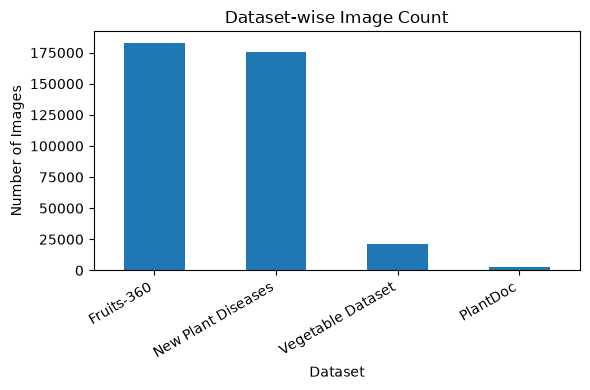

In [80]:
# Dataset-wise Image Count
dataset_image_count = (
    resolution_df
    .groupby("Dataset")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(6, 4))

dataset_image_count.plot(
    kind="bar"
)

plt.title("Dataset-wise Image Count")
plt.xlabel("Dataset")
plt.ylabel("Number of Images")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

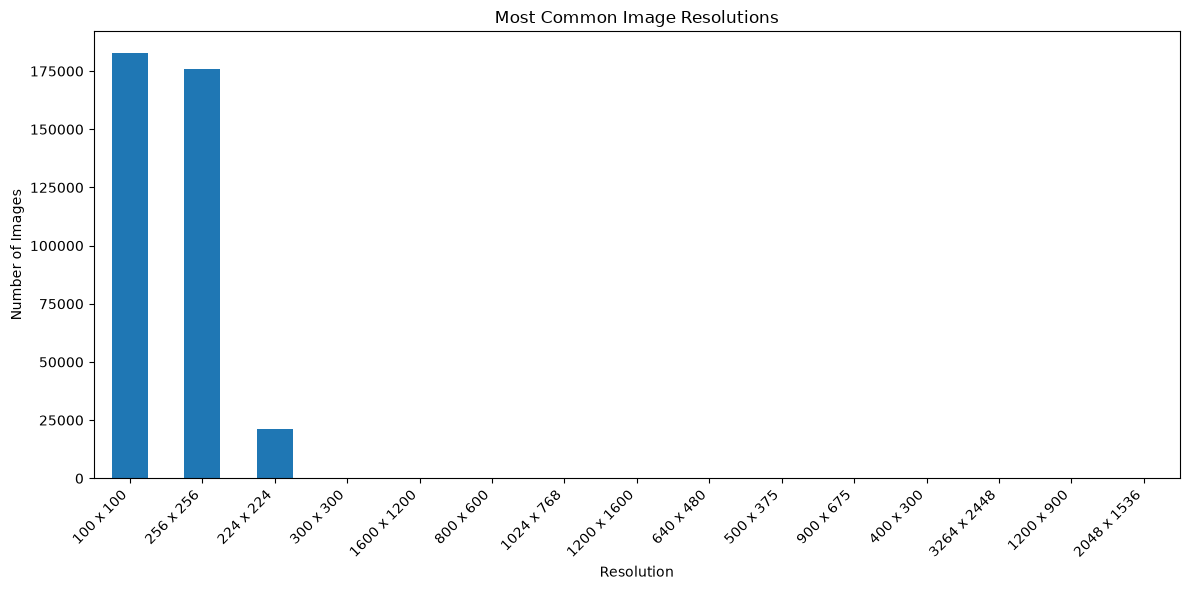

In [81]:
#  Resolution Distribution
resolution_distribution = (
    resolution_df["Resolution"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 6))

resolution_distribution.plot(
    kind="bar"
)

plt.title("Most Common Image Resolutions")
plt.xlabel("Resolution")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

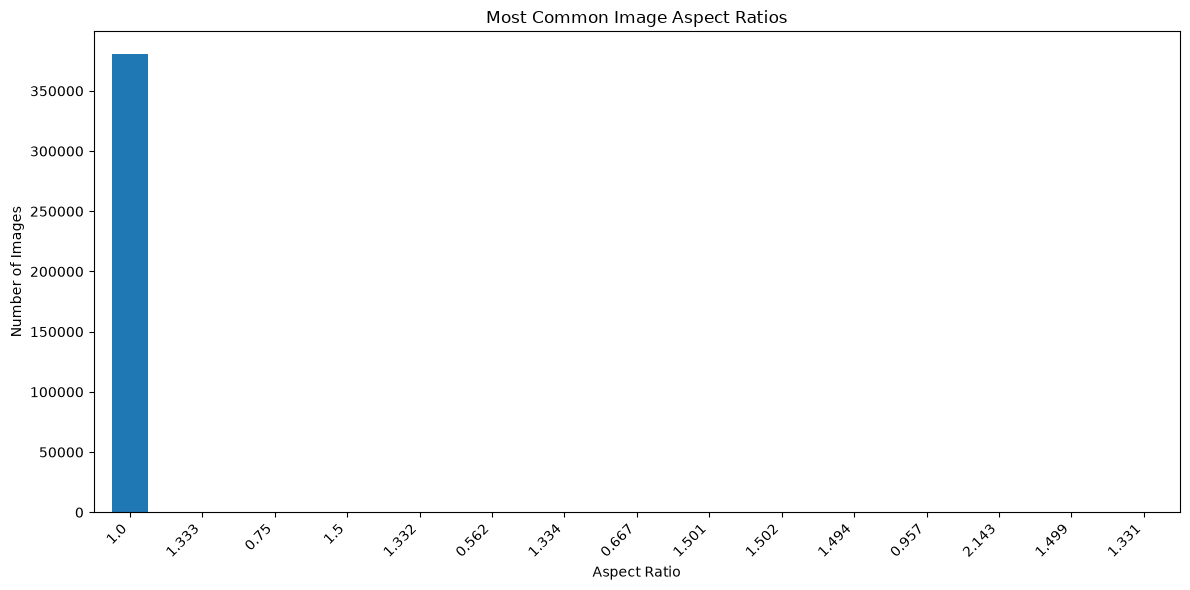

In [82]:
# Aspect Ratio Distribution
aspect_ratio_distribution = (
    resolution_df["Aspect_Ratio"]
    .round(3)
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 6))

aspect_ratio_distribution.plot(
    kind="bar"
)

plt.title("Most Common Image Aspect Ratios")
plt.xlabel("Aspect Ratio")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

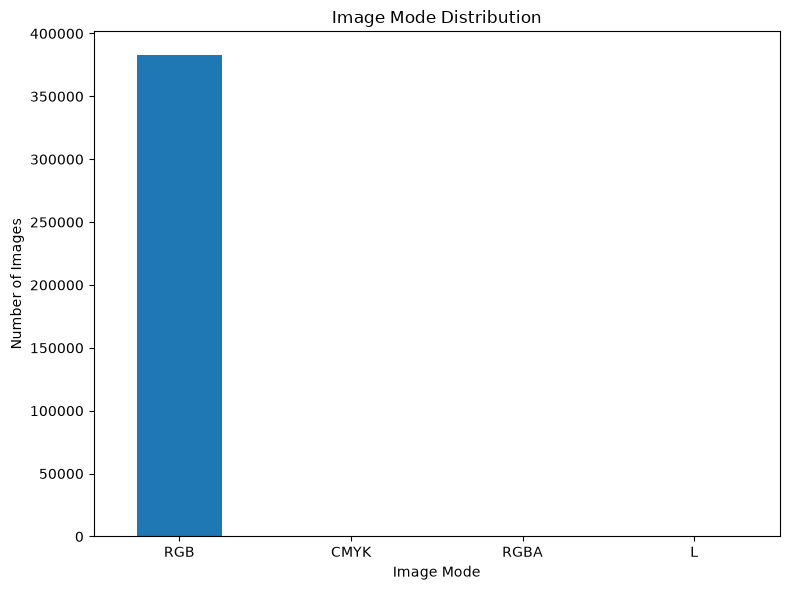

In [83]:
# Image Mode Distribution
mode_distribution = (
    resolution_df["Mode"]
    .value_counts()
)

plt.figure(figsize=(8, 6))

mode_distribution.plot(
    kind="bar"
)

plt.title("Image Mode Distribution")
plt.xlabel("Image Mode")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

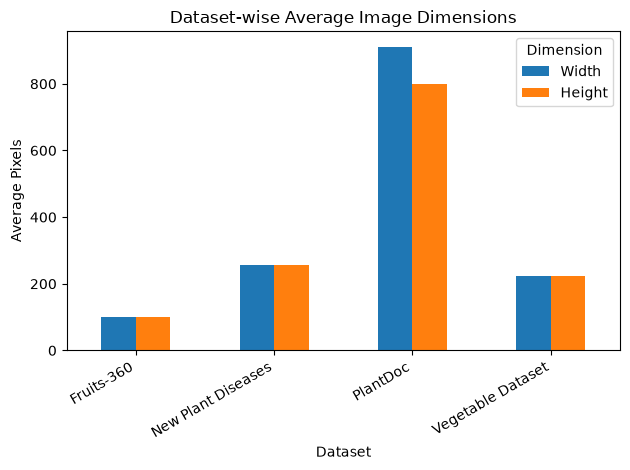

In [84]:
# Dataset-wise Average Resolution
average_resolution = (
    resolution_df
    .groupby("Dataset")[["Width", "Height"]]
    .mean()
)

plt.figure(figsize=(12, 6))

average_resolution.plot(
    kind="bar"
)

plt.title("Dataset-wise Average Image Dimensions")
plt.xlabel("Dataset")
plt.ylabel("Average Pixels")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Dimension")

plt.tight_layout()
plt.show()

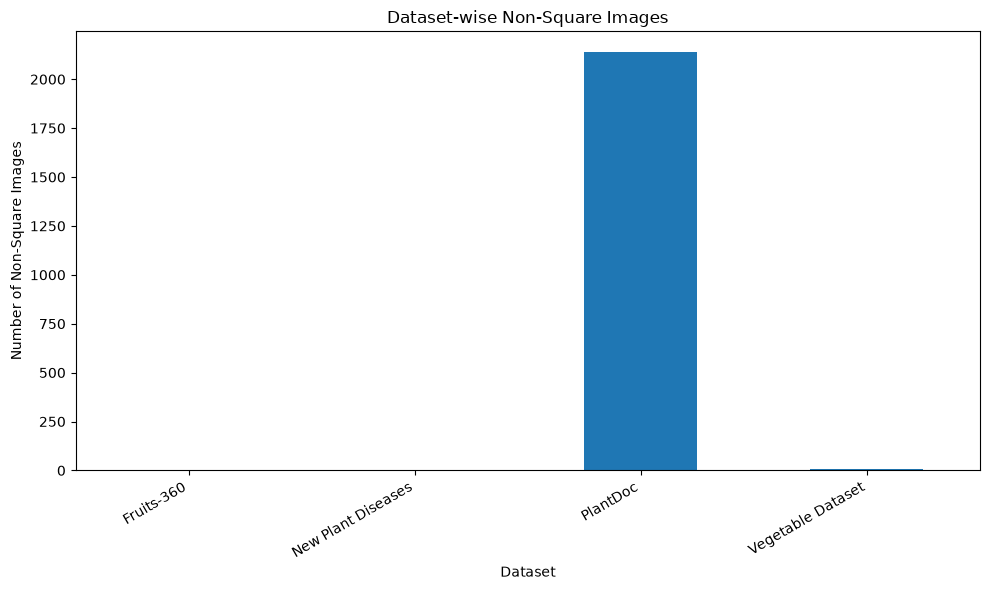

In [85]:
# Dataset-wise Non-Square Images
non_square_by_dataset = (
    resolution_df[
        resolution_df["Width"] != resolution_df["Height"]
    ]
    .groupby("Dataset")
    .size()
    .reindex(datasets.keys(), fill_value=0)
)

plt.figure(figsize=(10, 6))

non_square_by_dataset.plot(
    kind="bar"
)

plt.title("Dataset-wise Non-Square Images")
plt.xlabel("Dataset")
plt.ylabel("Number of Non-Square Images")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

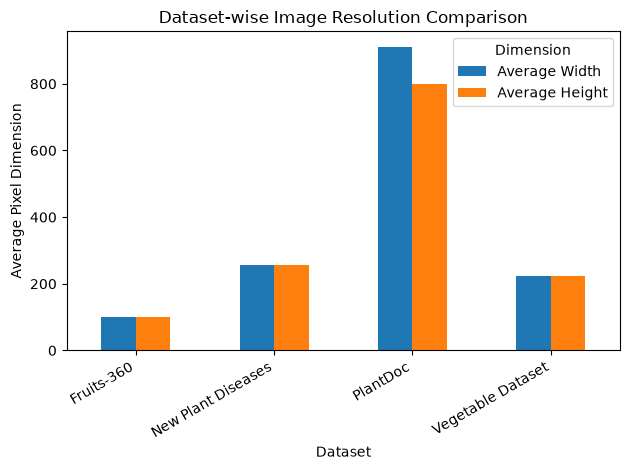

In [86]:
# Dataset-wise Image Quality / Resolution Comparison
quality_resolution = (
    resolution_df
    .groupby("Dataset")[["Width", "Height"]]
    .mean()
    .reindex(datasets.keys())
)

plt.figure(figsize=(12, 6))

quality_resolution.plot(
    kind="bar"
)

plt.title("Dataset-wise Image Resolution Comparison")
plt.xlabel("Dataset")
plt.ylabel("Average Pixel Dimension")
plt.xticks(rotation=30, ha="right")
plt.legend(
    title="Dimension",
    labels=["Average Width", "Average Height"]
)

plt.tight_layout()
plt.show()

# DATASET VISUALIZATION / STATISTICAL CHARTS

In [88]:
#  DATASET DISTRIBUTION
dataset_summary = df_statistics.copy()
display(dataset_summary)

,Dataset,Classes,Train Images,Test Images,Validation Images,Total Images
0,Fruits-360,260,137221,45724,0,182945
1,New Plant Diseases,38,140590,0,35144,175734
2,PlantDoc,28,2670,252,0,2922
3,Vegetable Dataset,15,15000,3000,3000,21000


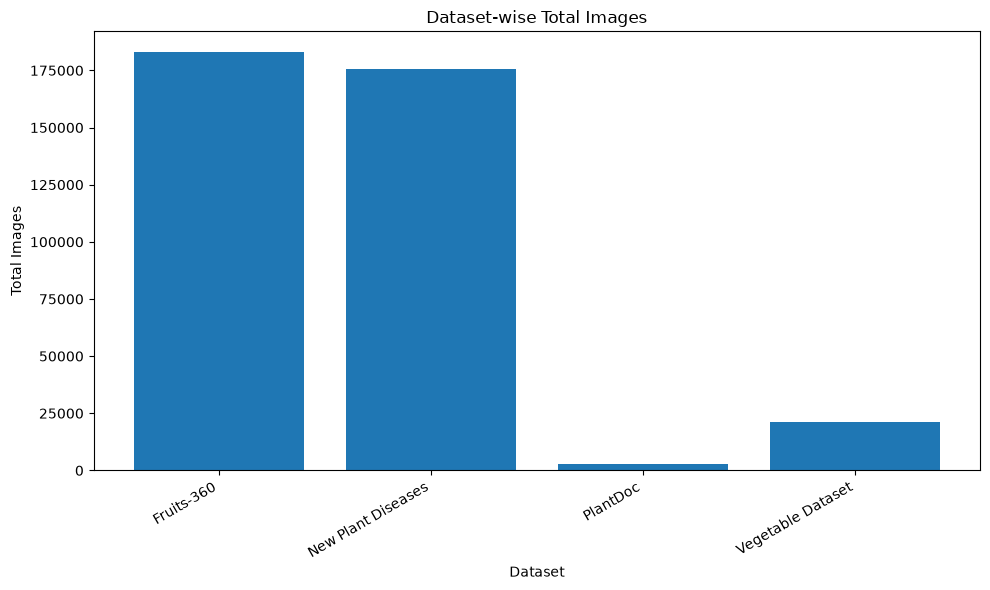

In [89]:
# Dataset-wise Total Images
plt.figure(figsize=(10, 6))

plt.bar(
    dataset_summary["Dataset"],
    dataset_summary["Total Images"]
)

plt.title("Dataset-wise Total Images")
plt.xlabel("Dataset")
plt.ylabel("Total Images")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

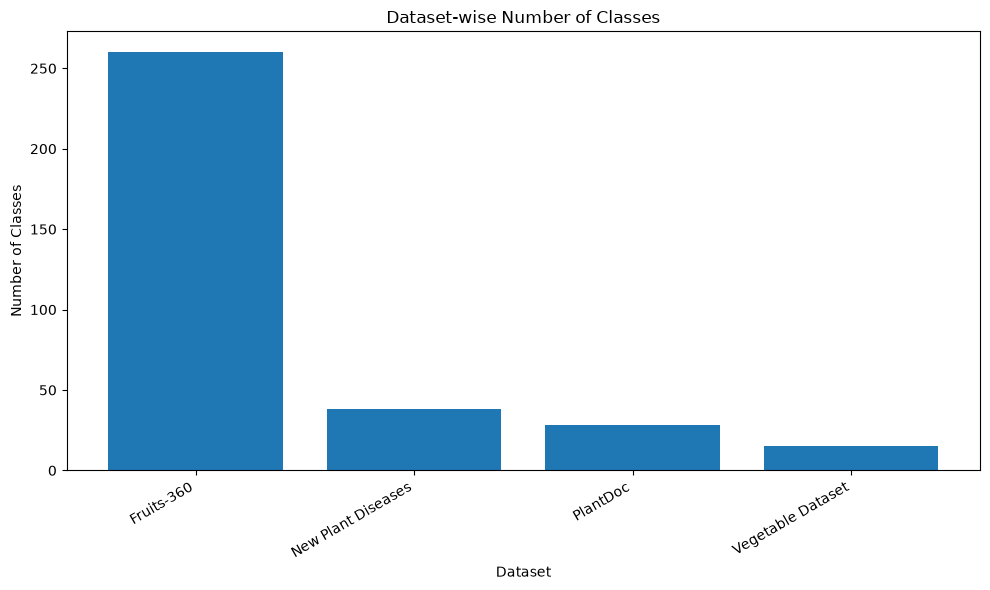

In [90]:
# DATASET-WISE CLASSES
plt.figure(figsize=(10, 6))

plt.bar(
    dataset_summary["Dataset"],
    dataset_summary["Classes"]
)

plt.title("Dataset-wise Number of Classes")
plt.xlabel("Dataset")
plt.ylabel("Number of Classes")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

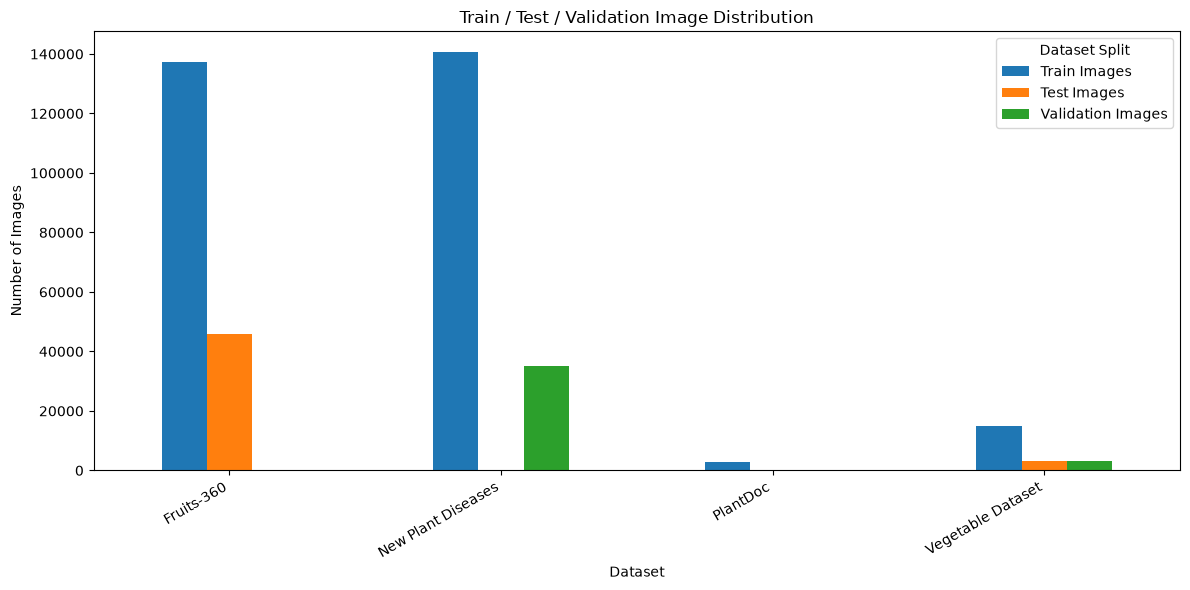

In [91]:
# RAIN / TEST / VALIDATION DISTRIBUTION
split_data = dataset_summary[
    [
        "Dataset",
        "Train Images",
        "Test Images",
        "Validation Images"
    ]
].set_index("Dataset")

split_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Train / Test / Validation Image Distribution")
plt.xlabel("Dataset")
plt.ylabel("Number of Images")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Dataset Split")

plt.tight_layout()
plt.show()

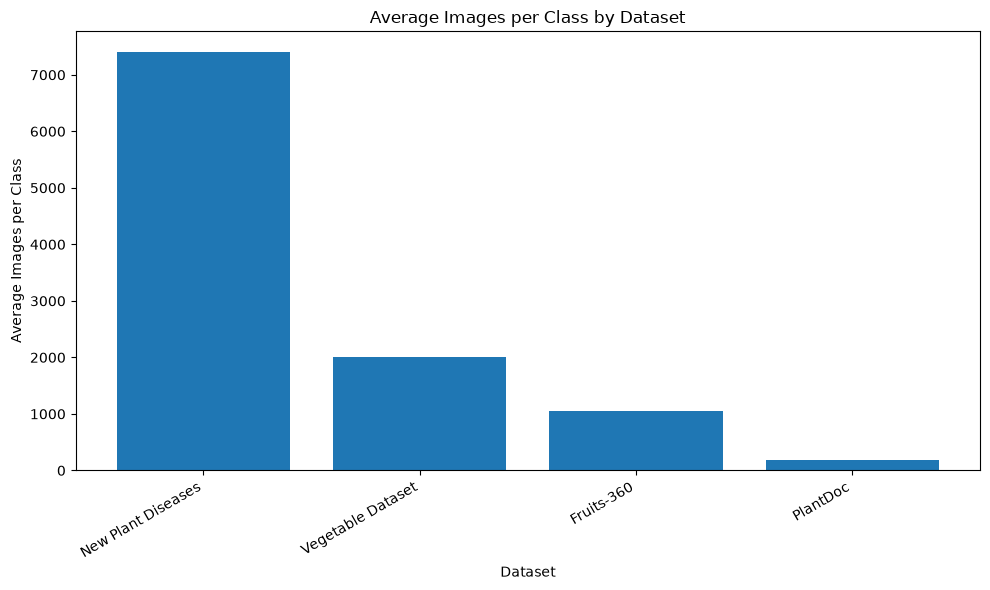

In [92]:
# AVERAGE IMAGES PER CLASS
class_average = (
    df_classes
    .groupby("Dataset")["Images"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    class_average.index,
    class_average.values
)

plt.title("Average Images per Class by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Average Images per Class")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

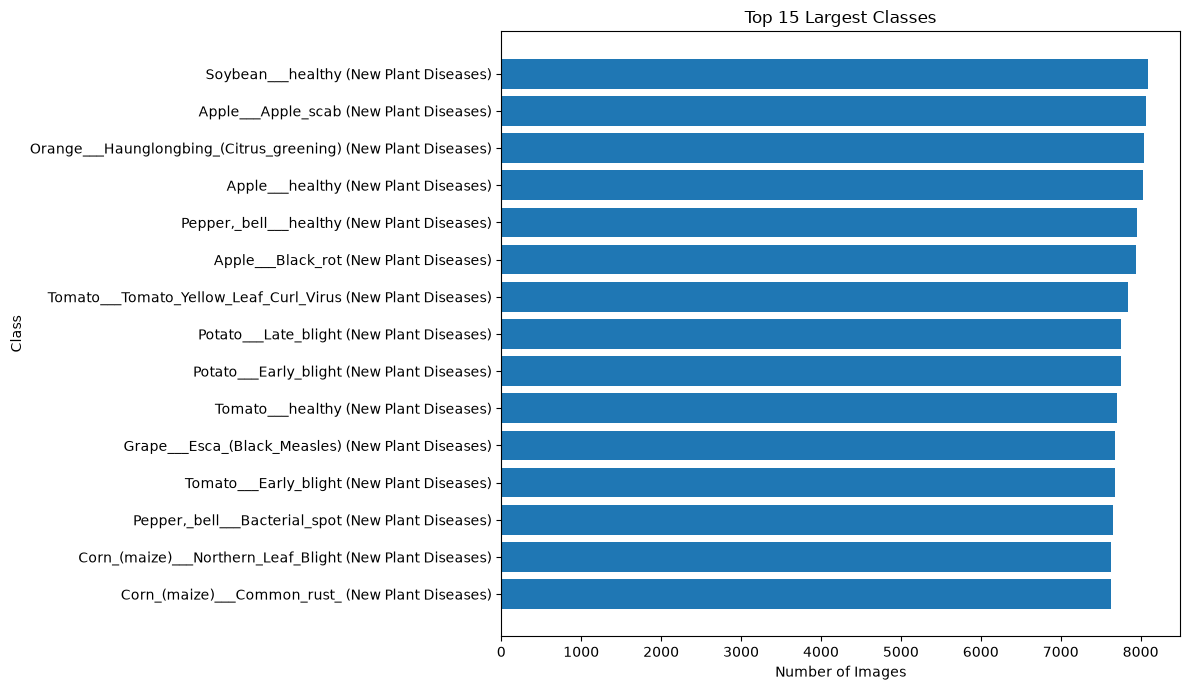

In [94]:
# LARGEST CLASSES
largest_classes = (
    df_classes
    .nlargest(15, "Images")
    .sort_values("Images", ascending=True)
    .copy()
)

largest_classes["Class Label"] = (
    largest_classes["Class"].astype(str)
    + " (" +
    largest_classes["Dataset"].astype(str)
    + ")"
)

plt.figure(figsize=(12, 7))

plt.barh(
    largest_classes["Class Label"],
    largest_classes["Images"]
)

plt.title("Top 15 Largest Classes")
plt.xlabel("Number of Images")
plt.ylabel("Class")

plt.tight_layout()
plt.show()

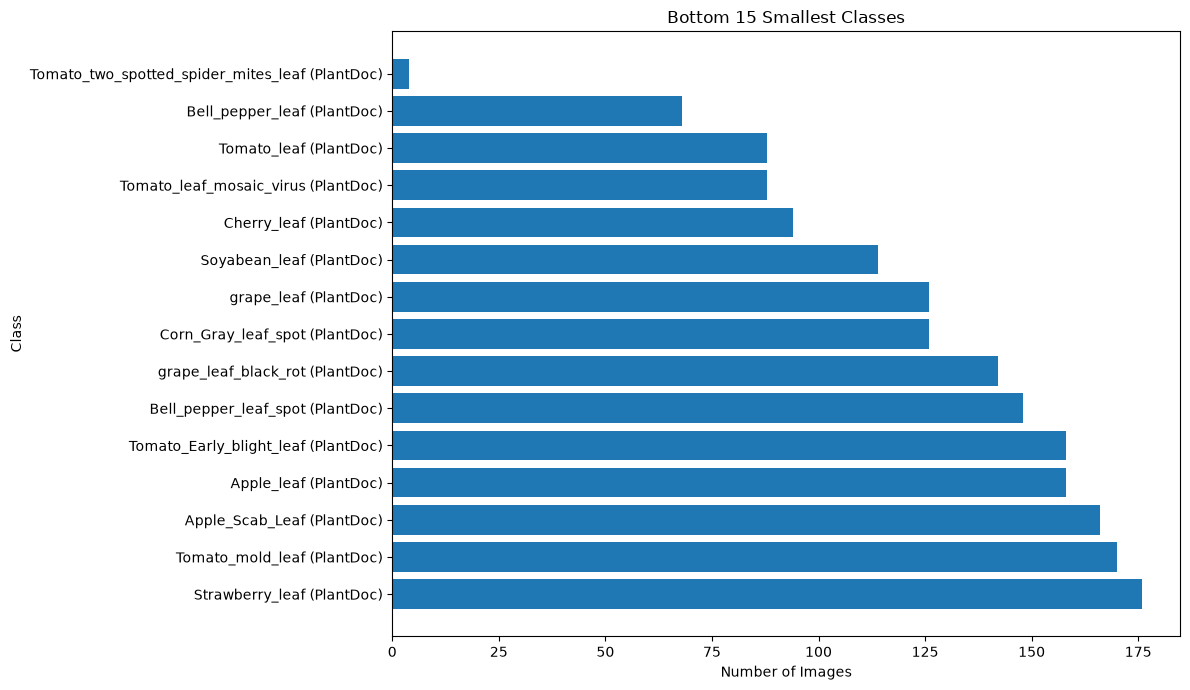

In [95]:
# SMALLEST CLASSES
smallest_classes = (
    df_classes
    .nsmallest(15, "Images")
    .sort_values("Images", ascending=False)
    .copy()
)

smallest_classes["Class Label"] = (
    smallest_classes["Class"].astype(str)
    + " (" +
    smallest_classes["Dataset"].astype(str)
    + ")"
)

plt.figure(figsize=(12, 7))

plt.barh(
    smallest_classes["Class Label"],
    smallest_classes["Images"]
)

plt.title("Bottom 15 Smallest Classes")
plt.xlabel("Number of Images")
plt.ylabel("Class")

plt.tight_layout()
plt.show()

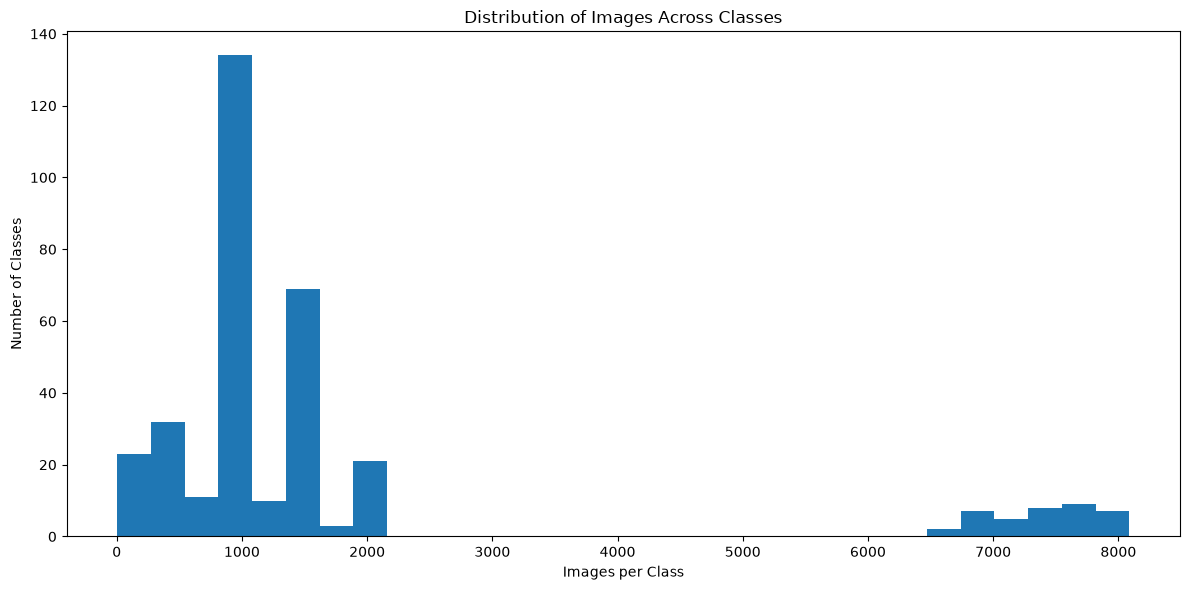

In [96]:
# CLASS IMAGE DISTRIBUTION
plt.figure(figsize=(12, 6))

plt.hist(
    df_classes["Images"],
    bins=30
)

plt.title("Distribution of Images Across Classes")
plt.xlabel("Images per Class")
plt.ylabel("Number of Classes")

plt.tight_layout()
plt.show()

# Dataset Summary Report

In [97]:
# OVERALL DATASET SUMMARY
total_datasets = len(df_statistics)

total_classes = df_statistics["Classes"].sum()

total_train = df_statistics["Train Images"].sum()

total_test = df_statistics["Test Images"].sum()

total_validation = df_statistics["Validation Images"].sum()

total_images = df_statistics["Total Images"].sum()


print("=" * 100)
print("OVERALL DATASET SUMMARY")
print("=" * 100)

print(f"Total Datasets       : {total_datasets}")
print(f"Total Classes        : {total_classes:,}")
print(f"Total Train Images   : {total_train:,}")
print(f"Total Test Images    : {total_test:,}")
print(f"Total Validation     : {total_validation:,}")
print(f"Total Images         : {total_images:,}")

print("=" * 100)

OVERALL DATASET SUMMARY
Total Datasets       : 4
Total Classes        : 341
Total Train Images   : 295,481
Total Test Images    : 48,976
Total Validation     : 38,144
Total Images         : 382,601


In [98]:
# Dataset-wise Summary Table
summary_report = df_statistics[
    [
        "Dataset",
        "Classes",
        "Train Images",
        "Test Images",
        "Validation Images",
        "Total Images"
    ]
].copy()

print("=" * 100)
print("DATASET-WISE SUMMARY")
print("=" * 100)

display(summary_report)

DATASET-WISE SUMMARY


,Dataset,Classes,Train Images,Test Images,Validation Images,Total Images
0,Fruits-360,260,137221,45724,0,182945
1,New Plant Diseases,38,140590,0,35144,175734
2,PlantDoc,28,2670,252,0,2922
3,Vegetable Dataset,15,15000,3000,3000,21000


In [99]:
# Dataset Percentage Contribution
summary_report["Image Contribution (%)"] = (
    summary_report["Total Images"] /
    total_images * 100
).round(2)

print("=" * 100)
print("DATASET IMAGE CONTRIBUTION")
print("=" * 100)

display(
    summary_report[
        [
            "Dataset",
            "Total Images",
            "Image Contribution (%)"
        ]
    ]
)

DATASET IMAGE CONTRIBUTION


,Dataset,Total Images,Image Contribution (%)
0,Fruits-360,182945,47.82
1,New Plant Diseases,175734,45.93
2,PlantDoc,2922,0.76
3,Vegetable Dataset,21000,5.49


In [100]:
# Train/Test/Validation Percentage
split_report = summary_report[
    [
        "Dataset",
        "Train Images",
        "Test Images",
        "Validation Images"
    ]
].copy()

split_report["Train (%)"] = (
    split_report["Train Images"] /
    split_report[
        ["Train Images", "Test Images", "Validation Images"]
    ].sum(axis=1) * 100
).round(2)

split_report["Test (%)"] = (
    split_report["Test Images"] /
    split_report[
        ["Train Images", "Test Images", "Validation Images"]
    ].sum(axis=1) * 100
).round(2)

split_report["Validation (%)"] = (
    split_report["Validation Images"] /
    split_report[
        ["Train Images", "Test Images", "Validation Images"]
    ].sum(axis=1) * 100
).round(2)

print("=" * 100)
print("TRAIN / TEST / VALIDATION PERCENTAGE")
print("=" * 100)

display(
    split_report[
        [
            "Dataset",
            "Train (%)",
            "Test (%)",
            "Validation (%)"
        ]
    ]
)

TRAIN / TEST / VALIDATION PERCENTAGE


,Dataset,Train (%),Test (%),Validation (%)
0,Fruits-360,75.01,24.99,0.00
1,New Plant Diseases,80.00,0.00,20.00
2,PlantDoc,91.38,8.62,0.00
3,Vegetable Dataset,71.43,14.29,14.29


In [101]:
# Dataset Structure Status
structure_report = df_detection[
    [
        "Dataset",
        "Train Folder",
        "Test Folder",
        "Validation Folder"
    ]
].copy()

display(structure_report)

,Dataset,Train Folder,Test Folder,Validation Folder
0,Fruits-360,Training,Test,Not Found
1,New Plant Diseases,train,Not Found,valid
2,PlantDoc,train,test,Not Found
3,Vegetable Dataset,train,test,validation


In [102]:
# Missing DATASET SPLITS
missing_train = (
    df_detection["Train Folder"] == "Not Found"
).sum()

missing_test = (
    df_detection["Test Folder"] == "Not Found"
).sum()

missing_validation = (
    df_detection["Validation Folder"] == "Not Found"
).sum()

print("=" * 100)
print("MISSING DATASET SPLITS")
print("=" * 100)

print(f"Missing Train Folder      : {missing_train}")
print(f"Missing Test Folder       : {missing_test}")
print(f"Missing Validation Folder : {missing_validation}")


MISSING DATASET SPLITS
Missing Train Folder      : 0
Missing Test Folder       : 1
Missing Validation Folder : 2


In [103]:
# LARGEST DATASET
largest_dataset = summary_report.loc[
    summary_report["Total Images"].idxmax()
]

print("=" * 100)
print("LARGEST DATASET")
print("=" * 100)

print(f"Dataset      : {largest_dataset['Dataset']}")
print(f"Classes      : {largest_dataset['Classes']:,}")
print(f"Total Images : {largest_dataset['Total Images']:,}")

LARGEST DATASET
Dataset      : Fruits-360
Classes      : 260
Total Images : 182,945


In [104]:
# Smallest Dataset
smallest_dataset = summary_report.loc[
    summary_report["Total Images"].idxmin()
]

print("=" * 100)
print("SMALLEST DATASET")
print("=" * 100)

print(f"Dataset      : {smallest_dataset['Dataset']}")
print(f"Classes      : {smallest_dataset['Classes']:,}")
print(f"Total Images : {smallest_dataset['Total Images']:,}")

SMALLEST DATASET
Dataset      : PlantDoc
Classes      : 28
Total Images : 2,922


In [105]:
#  FINAL DATASET ANALYSIS
print("\n")
print("=" * 100)
print("                    FINAL DATASET ANALYSIS REPORT")
print("=" * 100)

print("\n1. DATASET OVERVIEW")
print("-" * 100)
print(f"Total Datasets       : {total_datasets}")
print(f"Total Classes        : {total_classes:,}")
print(f"Total Images         : {total_images:,}")

print("\n2. IMAGE DISTRIBUTION")
print("-" * 100)
print(f"Train Images         : {total_train:,}")
print(f"Test Images          : {total_test:,}")
print(f"Validation Images    : {total_validation:,}")

print("\n3. LARGEST DATASET")
print("-" * 100)
print(f"Dataset              : {largest_dataset['Dataset']}")
print(f"Total Images         : {largest_dataset['Total Images']:,}")

print("\n4. SMALLEST DATASET")
print("-" * 100)
print(f"Dataset              : {smallest_dataset['Dataset']}")
print(f"Total Images         : {smallest_dataset['Total Images']:,}")

print("\n5. DATASET STRUCTURE")
print("-" * 100)
print(f"Missing Train Folder      : {missing_train}")
print(f"Missing Test Folder       : {missing_test}")
print(f"Missing Validation Folder : {missing_validation}")

print("\n6. ANALYSIS STATUS")
print("-" * 100)
print("Dataset structure analysis       : COMPLETED")
print("Image count analysis             : COMPLETED")
print("Class count analysis             : COMPLETED")
print("Duplicate class analysis         : COMPLETED")
print("Train/Test/Validation analysis   : COMPLETED")
print("Resolution analysis              : COMPLETED")
print("Aspect ratio analysis            : COMPLETED")
print("Image mode analysis              : COMPLETED")
print("Image quality analysis           : COMPLETED")
print("Visualization and charts         : COMPLETED")




                    FINAL DATASET ANALYSIS REPORT

1. DATASET OVERVIEW
----------------------------------------------------------------------------------------------------
Total Datasets       : 4
Total Classes        : 341
Total Images         : 382,601

2. IMAGE DISTRIBUTION
----------------------------------------------------------------------------------------------------
Train Images         : 295,481
Test Images          : 48,976
Validation Images    : 38,144

3. LARGEST DATASET
----------------------------------------------------------------------------------------------------
Dataset              : Fruits-360
Total Images         : 182,945

4. SMALLEST DATASET
----------------------------------------------------------------------------------------------------
Dataset              : PlantDoc
Total Images         : 2,922

5. DATASET STRUCTURE
----------------------------------------------------------------------------------------------------
Missing Train Folder      : 0
Missin

In [106]:
# FINAL REPORT TABLE

final_report = pd.DataFrame({
    "Metric": [
        "Total Datasets",
        "Total Classes",
        "Total Images",
        "Train Images",
        "Test Images",
        "Validation Images",
        "Largest Dataset",
        "Smallest Dataset",
        "Missing Test Folders",
        "Missing Validation Folders"
    ],
    
    "Value": [
        total_datasets,
        total_classes,
        total_images,
        total_train,
        total_test,
        total_validation,
        largest_dataset["Dataset"],
        smallest_dataset["Dataset"],
        missing_test,
        missing_validation
    ]
})

print("=" * 100)
print("FINAL SUMMARY TABLE")
print("=" * 100)

display(final_report)

FINAL SUMMARY TABLE


,Metric,Value
0,Total Datasets,4
1,Total Classes,341
2,Total Images,382601
3,Train Images,295481
4,Test Images,48976
5,Validation Images,38144
6,Largest Dataset,Fruits-360
7,Smallest Dataset,PlantDoc
8,Missing Test Folders,1
9,Missing Validation Folders,2
